In [1]:
pip install tensorflow opencv-python matplotlib scikit-learn numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
data = []
labels = []

dataset_path = "dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

classes = ["Normal","Cyst","Tumor","Stone"]

for label in classes:

    folder = os.path.join(dataset_path,label)

    for img in os.listdir(folder):

        img_path = os.path.join(folder,img)

        image = cv2.imread(img_path)

        image = cv2.resize(image,(128,128))

        data.append(image)
        labels.append(classes.index(label))

data = np.array(data)
labels = np.array(labels)

print("Dataset Shape:",data.shape)

Dataset Shape: (12446, 128, 128, 3)


In [4]:
data = data / 255.0

In [5]:
labels = to_categorical(labels,4)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(9956, 128, 128, 3)
(2490, 128, 128, 3)


In [7]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 98s 294ms/step - accuracy: 0.8702 - loss: 0.3433 - val_accuracy: 0.9988 - val_loss: 0.0150
Epoch 2/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 139s 284ms/step - accuracy: 0.9868 - loss: 0.0445 - val_accuracy: 0.9980 - val_loss: 0.0108
Epoch 3/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 85s 273ms/step - accuracy: 0.9911 - loss: 0.0262 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 87s 279ms/step - accuracy: 0.9944 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 5.7796e-04
Epoch 5/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - accuracy: 0.9959 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 9.4951e-04
Epoch 6/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 69s 221ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 6.6379e-04
Epoch 7/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 115s 369ms/step - accuracy: 0.9968 - loss: 0.0094 - val_accuracy: 0.9996 - val_loss: 0.0014
Epoch 8/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 113s 361ms/step - accuracy: 0

In [9]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 1.0000 - loss: 6.7275e-06
Test Accuracy: 1.0


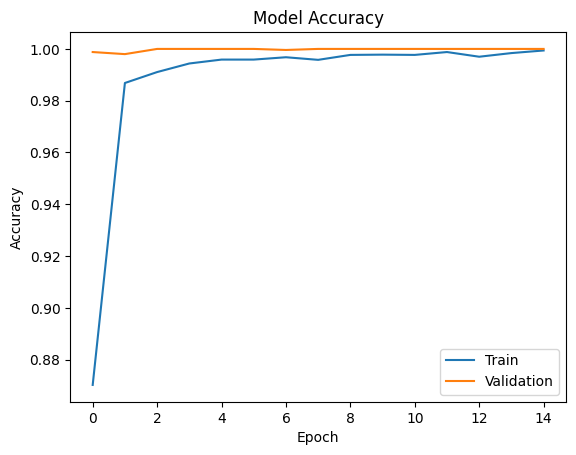

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [11]:
img = cv2.imread("test.jpg")

img = cv2.resize(img,(128,128))

img = img/255.0

img = np.reshape(img,(1,128,128,3))

prediction = model.predict(img)

classes = ["Normal","Cyst","Tumor","Stone"]

print("Prediction:",classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
Prediction: Cyst


In [13]:
model.save("kidney_model.keras")

In [16]:
from tensorflow.keras.models import load_model

model = load_model("kidney_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step


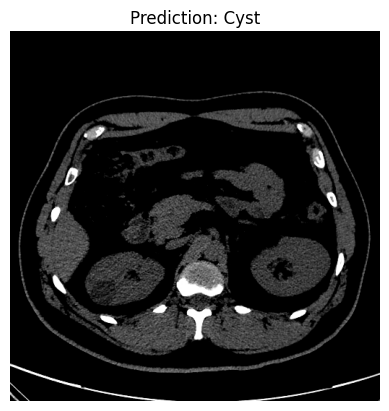

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load image
img_path = "test.jpg"   # put your test image name here

img = cv2.imread(img_path)

# convert BGR to RGB for correct display
img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# resize for model
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.reshape(img,(1,128,128,3))

# prediction
prediction = model.predict(img)

classes = ["Normal","Cyst","Tumor","Stone"]
result = classes[np.argmax(prediction)]

# show image
plt.imshow(img_display)
plt.title("Prediction: " + result)
plt.axis("off")
plt.show()